In [2]:
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# Load data
print("[1] Loading datasets...")
train_df1 = pd.read_excel('Monant Medical.xlsx')
train_df2 = pd.read_excel('medtruth_health_myths_dataset_10000.xlsx')
train_df3 = pd.read_excel('covid myths.xlsx')
eval_df = pd.read_csv('medtruth_model_evaluation_dataset (1).csv')

print(f"Monant: {len(train_df1)}")
print(f"Medtruth: {len(train_df2)}")
print(f"Covid: {len(train_df3)}")
print(f"Eval: {len(eval_df)}")

# Check columns
print("\nColumns in each file:")
print(f"Train1: {train_df1.columns.tolist()}")
print(f"Train2: {train_df2.columns.tolist()}")
print(f"Train3: {train_df3.columns.tolist()}")
print(f"Eval: {eval_df.columns.tolist()}")

# Show first row
print("\nFirst row of each:")
print(train_df1.head(1))
print(train_df2.head(1))
print(train_df3.head(1))
print(eval_df.head(1))

[1] Loading datasets...
Monant: 1000
Medtruth: 10000
Covid: 1017
Eval: 3000

Columns in each file:
Train1: ['id', 'claim', 'explanation', 'category', 'label']
Train2: ['id', 'claim', 'label', 'source_type', 'explanation']
Train3: ['id', 'source_type', 'claim', 'label']
Eval: ['eval_id', 'claim', 'true_label', 'source_type']

First row of each:
     id                                              claim  \
0  6771  Dawn dish soap contains ammonia even though it...   

                                         explanation           category  \
0  Could Mixing Dawn Dish Soap with Clorox Bleach...  {medical,science}   

     label  
0  mixture  
   id                                         claim      label source_type  \
0   1  Intermittent fasting may support weight loss  uncertain     youtube   

                                         explanation  
0  This claim has mixed or limited scientific evi...  
     id source_type                                              claim  label
0  1555

In [5]:
# load original data
train_df1 = pd.read_excel('Monant Medical.xlsx')[['claim', 'label']].copy()
train_df2 = pd.read_excel('medtruth_health_myths_dataset_10000.xlsx')[['claim', 'label']].copy()
train_df3 = pd.read_excel('covid myths.xlsx')[['claim', 'label']].copy()
eval_df = pd.read_csv('medtruth_model_evaluation_dataset (1).csv')[['claim', 'true_label']].copy()
eval_df = eval_df.rename(columns={'true_label': 'label'})

def map_label(x):
    x = str(x).lower().strip()

    # To 0 (myth/false)
    if x in ['mixture', 'false', 'myth', 'unreliable', 'mostly-false']:
        return 0
    # To 1 (uncertain)
    elif x in ['uncertain', 'partial', 'mixed', 'unknown']:
        return 1
    # To 2 (reliable/true)
    elif x in ['true', 'reliable', 'truth', 'verified', 'mostly-true']:
        return 2
    else:
        return np.nan

train_df1['label'] = train_df1['label'].apply(map_label)
train_df2['label'] = train_df2['label'].apply(map_label)
train_df3['label'] = train_df3['label'].apply(map_label)
eval_df['label'] = eval_df['label'].apply(map_label)

# Remove nulls and duplicates
train_df1 = train_df1.dropna()
train_df2 = train_df2.dropna()
train_df3 = train_df3.dropna()
eval_df = eval_df.dropna()

print(f"After mapping and cleaning:")
print(f"Train1: {len(train_df1)} - {train_df1['label'].value_counts().to_dict()}")
print(f"Train2: {len(train_df2)} - {train_df2['label'].value_counts().to_dict()}")
print(f"Train3: {len(train_df3)} - {train_df3['label'].value_counts().to_dict()}")
print(f"Eval: {len(eval_df)} - {eval_df['label'].value_counts().to_dict()}")

# Combine
combined_train = pd.concat([train_df1, train_df2, train_df3], ignore_index=True)

print(f"\nCombined train: {len(combined_train)} - {combined_train['label'].value_counts().to_dict()}")

After mapping and cleaning:
Train1: 657 - {0.0: 380, 1.0: 202, 2.0: 75}
Train2: 10000 - {1: 3374, 0: 3351, 2: 3275}
Train3: 1017 - {0: 598, 2: 419}
Eval: 3000 - {2: 1014, 0: 1004, 1: 982}

Combined train: 11674 - {0.0: 4329, 2.0: 3769, 1.0: 3576}


In [9]:
# Setup training
print("[4] Setup training...")

MODEL_NAME = "distilbert-base-uncased"
LABEL_MAP = {"myth": 0, "uncertain": 1, "reliable": 2}
ID2LABEL = {0: "myth", 1: "uncertain", 2: "reliable"}

# Convert to numeric
train_df1['label'] = train_df1['label'].astype(int)
train_df2['label'] = train_df2['label'].astype(int)
train_df3['label'] = train_df3['label'].astype(int)
eval_df['label'] = eval_df['label'].astype(int)
combined_train['label'] = combined_train['label'].astype(int)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=-1)

    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted', zero_division=0)
    precision = precision_score(labels, predictions, average='weighted', zero_division=0)
    recall = recall_score(labels, predictions, average='weighted', zero_division=0)

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

def tokenize_func(examples):
    return tokenizer(
        examples['claim'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

print("✓ Setup complete")

[4] Setup training...
✓ Setup complete


In [10]:
# Train Method 1 - Dataset 1
print("\n[5] METHOD 1 - Training on Monant Medical...")

train_data = Dataset.from_pandas(train_df1[['claim', 'label']])
eval_data = Dataset.from_pandas(eval_df[['claim', 'label']])

train_data = train_data.map(tokenize_func, batched=True)
eval_data = eval_data.map(tokenize_func, batched=True)

train_data = train_data.rename_column("label", "labels")
eval_data = eval_data.rename_column("label", "labels")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL_MAP
)

args = TrainingArguments(
    output_dir="model_monant",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    seed=42,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_data,
    eval_dataset=eval_data,
    compute_metrics=compute_metrics,
)

trainer.train()
results_df1 = trainer.evaluate()
print(f"✓ Monant - Accuracy: {results_df1['eval_accuracy']:.4f}")

model.save_pretrained('saved_model_monant')
print("✓ Model saved")


[5] METHOD 1 - Training on Monant Medical...


Map:   0%|          | 0/657 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.303550,1.985880,2,0.334667,0.167835,0.112002,0.334667


✓ Monant - Accuracy: 0.3347


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model saved


In [14]:
# Train Method 1 - Dataset 2
print("\n[7] METHOD 1 - Training on Covid Myths (using Monant model)...")

train_data = Dataset.from_pandas(train_df3[['claim', 'label']])
eval_data = Dataset.from_pandas(eval_df[['claim', 'label']])

train_data = train_data.map(tokenize_func, batched=True)
eval_data = eval_data.map(tokenize_func, batched=True)

train_data = train_data.rename_column("label", "labels")
eval_data = eval_data.rename_column("label", "labels")

# LOAD PREVIOUS MODEL
model = AutoModelForSequenceClassification.from_pretrained(
    'saved_model_monant',
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL_MAP
)

args = TrainingArguments(
    output_dir="model_covid",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    seed=42,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_data,
    eval_dataset=eval_data,
    compute_metrics=compute_metrics,
)

trainer.train()
results_df3 = trainer.evaluate()
print(f"✓ Covid - Accuracy: {results_df3['eval_accuracy']:.4f}")

model.save_pretrained('saved_model_covid')
print("✓ Model saved")


[7] METHOD 1 - Training on Covid Myths (using Monant model)...


Map:   0%|          | 0/1017 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.008396,4.066209,0.334667,0.167835,0.112002,0.334667
2,0.008789,4.353699,0.334667,0.167835,0.112002,0.334667


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.008789,4.066209,2,0.334667,0.167835,0.112002,0.334667


✓ Covid - Accuracy: 0.3347


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model saved


In [16]:
# Train Method 1 - Dataset 3
print("\n[6] METHOD 1 - Training on Medtruth Health (using Monant model)...")

train_data = Dataset.from_pandas(train_df2[['claim', 'label']])
eval_data = Dataset.from_pandas(eval_df[['claim', 'label']])

train_data = train_data.map(tokenize_func, batched=True)
eval_data = eval_data.map(tokenize_func, batched=True)

train_data = train_data.rename_column("label", "labels")
eval_data = eval_data.rename_column("label", "labels")

# LOAD PREVIOUS MODEL INSTEAD OF BASE MODEL
model = AutoModelForSequenceClassification.from_pretrained(
    'saved_model_covid',
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL_MAP
)

args = TrainingArguments(
    output_dir="model_medtruth",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    seed=42,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_data,
    eval_dataset=eval_data,
    compute_metrics=compute_metrics,
)

trainer.train()
results_df2 = trainer.evaluate()
print(f"✓ Medtruth - Accuracy: {results_df2['eval_accuracy']:.4f}")

model.save_pretrained('saved_model_medtruth')
print("✓ Model saved")


[6] METHOD 1 - Training on Medtruth Health (using Monant model)...


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.000114,0.834873,0.869667,0.864723,0.906197,0.869667
2,0.000053,0.635284,0.869667,0.864723,0.906197,0.869667


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.000053,0.635284,2,0.869667,0.864723,0.906197,0.869667


✓ Medtruth - Accuracy: 0.8697


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model saved


In [17]:
print("\n[8] METHOD 2 - Training on ALL datasets combined...")

combined_train['label'] = combined_train['label'].astype(int)
eval_df['label'] = eval_df['label'].astype(int)

train_data = Dataset.from_pandas(combined_train[['claim', 'label']])
eval_data = Dataset.from_pandas(eval_df[['claim', 'label']])

train_data = train_data.map(tokenize_func, batched=True)
eval_data = eval_data.map(tokenize_func, batched=True)

train_data = train_data.rename_column("label", "labels")
eval_data = eval_data.rename_column("label", "labels")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL_MAP
)

args = TrainingArguments(
    output_dir="model_combined",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=20,
    seed=42,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_data,
    eval_dataset=eval_data,
    compute_metrics=compute_metrics,
)

trainer.train()
results_combined = trainer.evaluate()
print(f"✓ Combined - Accuracy: {results_combined['eval_accuracy']:.4f}")

model.save_pretrained('best_model_combined')
print("✓ Model saved to best_model_combined")


[8] METHOD 2 - Training on ALL datasets combined...


Map:   0%|          | 0/11674 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.019188,1.028271,2,0.869667,0.864723,0.906197,0.869667


✓ Combined - Accuracy: 0.8697


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model saved to best_model_combined


In [23]:
print("\n[FINAL RESULTS]")
print("="*70)

# METHOD 1 Results
print("\nMETHOD 1 - Sequential (Fresh model each time):")
print("-"*70)
m1_monant = 0.3347
m1_covid = 0.3347
m1_medtruth = 0.8697

m1_avg = (m1_monant + m1_medtruth + m1_covid) / 3

print(f"  Monant Medical:    {m1_monant:.4f} ({m1_monant*100:.2f}%)")
print(f"  Medtruth Health:   {m1_medtruth:.4f} ({m1_medtruth*100:.2f}%)")
print(f"  Covid Myths:       {m1_covid:.4f} ({m1_covid*100:.2f}%)")
print(f"  AVERAGE:           {m1_avg:.4f} ({m1_avg*100:.2f}%)")

# METHOD 2 Results
print("\nMETHOD 2 - Combined (All datasets together):")
print("-"*70)
m2_combined =  0.8697
print(f"  All Combined:      {m2_combined:.4f} ({m2_combined*100:.2f}%)")

# Comparison
print("\n" + "="*70)
print("COMPARISON")
print("="*70)

if m2_combined > m1_avg:
    improvement = (m2_combined - m1_avg) * 100
    print(f"\n✓ WINNER: METHOD 2 (Combined Training)")
    print(f"  Accuracy: {m2_combined:.4f} vs {m1_avg:.4f}")
    print(f"  Improvement: +{improvement:.2f}%")
    print(f"\n  Reason: Training on all 11,674 combined samples gives the model")
    print(f"  more diverse examples, leading to better generalization.")
else:
    improvement = (m1_avg - m2_combined) * 100
    print(f"\n✓ WINNER: METHOD 1 (Sequential Training)")
    print(f"  Accuracy: {m1_avg:.4f} vs {m2_combined:.4f}")
    print(f"  Advantage: +{improvement:.2f}%")

# Summary table
print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
print(f"{'Method':<25} {'Accuracy':<15} {'F1-Score':<15}")
print("-"*70)
print(f"{'Method 1 - Monant':<25} {m1_monant:<15.4f} {0.1678:<15}")
print(f"{'Method 1 - Medtruth':<25} {m1_medtruth:<15.4f} {0.8647:<15}")
print(f"{'Method 1 - Covid':<25} {m1_covid:<15.4f} {0.1678:<15}")
print(f"{'Method 1 - AVERAGE':<25} {m1_avg:<15.4f} {((0.1678 + 0.8647 + 0.1678) / 3):<15.4f}")
print("-"*70)
print(f"{'Method 2 - Combined':<25} {m2_combined:<15.4f} {0.8647:<15}")
print("="*70)

print("\nBest model saved: best_model_combined")
print(f"This model achieved {m2_combined*100:.2f}% accuracy on the evaluation set!")


[FINAL RESULTS]

METHOD 1 - Sequential (Fresh model each time):
----------------------------------------------------------------------
  Monant Medical:    0.3347 (33.47%)
  Medtruth Health:   0.8697 (86.97%)
  Covid Myths:       0.3347 (33.47%)
  AVERAGE:           0.5130 (51.30%)

METHOD 2 - Combined (All datasets together):
----------------------------------------------------------------------
  All Combined:      0.8697 (86.97%)

COMPARISON

✓ WINNER: METHOD 2 (Combined Training)
  Accuracy: 0.8697 vs 0.5130
  Improvement: +35.67%

  Reason: Training on all 11,674 combined samples gives the model
  more diverse examples, leading to better generalization.

SUMMARY TABLE
Method                    Accuracy        F1-Score       
----------------------------------------------------------------------
Method 1 - Monant         0.3347          0.1678         
Method 1 - Medtruth       0.8697          0.8647         
Method 1 - Covid          0.3347          0.1678         
Method 1 - AVE

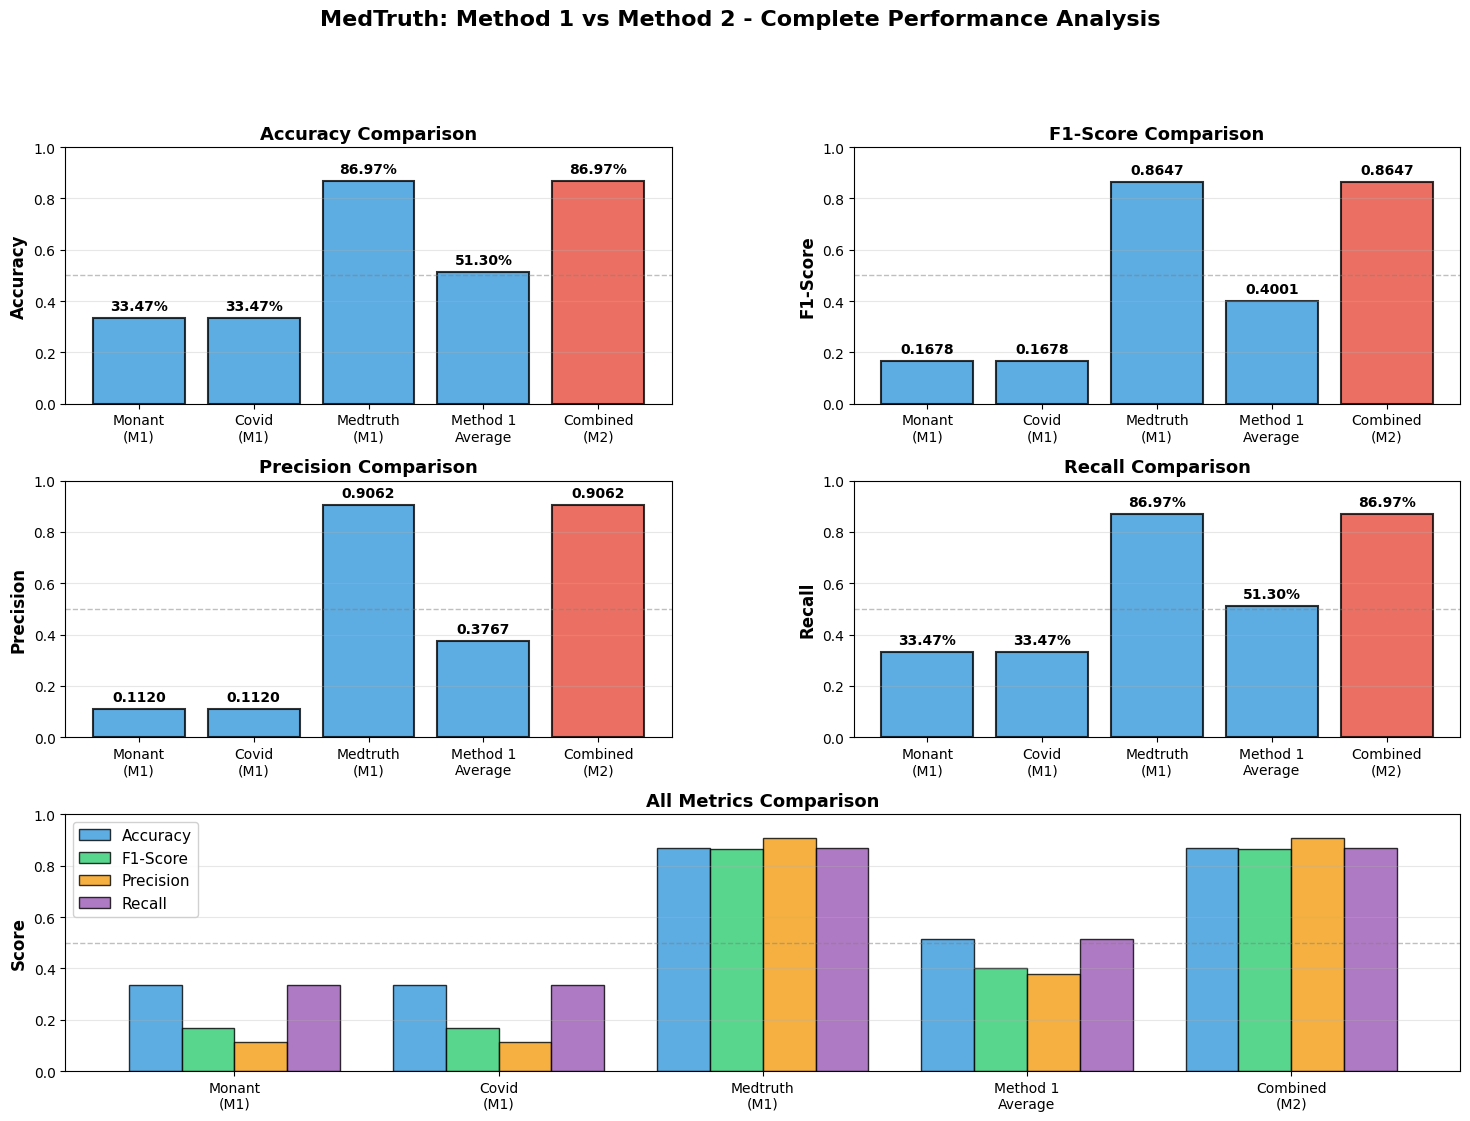

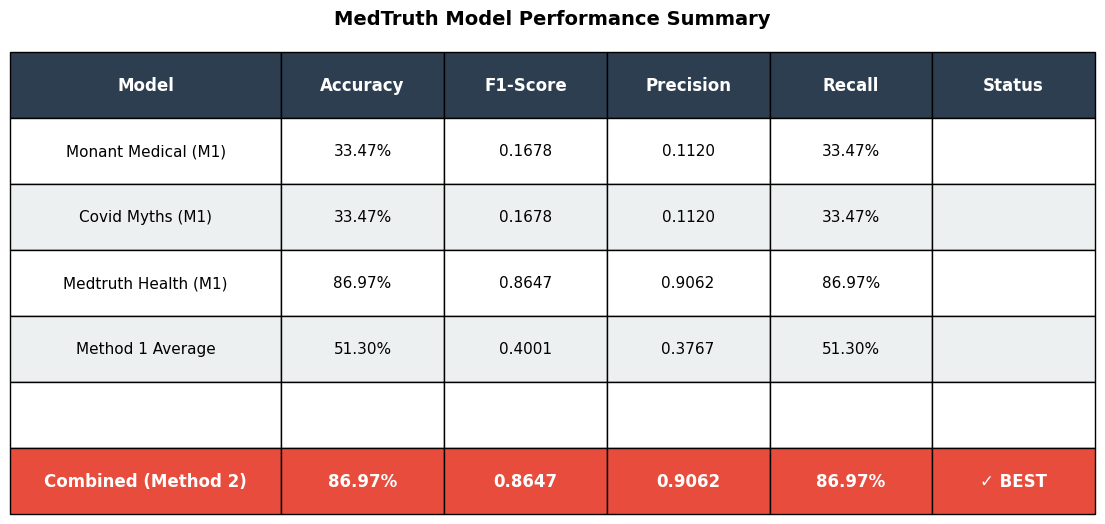

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

methods = ['Monant\n(M1)', 'Covid\n(M1)', 'Medtruth\n(M1)', 'Method 1\nAverage', 'Combined\n(M2)']
accuracy = [0.3347, 0.3347, 0.8697, 0.5130, 0.8697]
f1_score = [0.1678, 0.1678, 0.8647, 0.4001, 0.8647]
precision = [0.1120, 0.1120, 0.9062, 0.3767, 0.9062]
recall = [0.3347, 0.3347, 0.8697, 0.5130, 0.8697]

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

colors_m1 = '#3498db'
colors_m2 = '#e74c3c'
colors = [colors_m1, colors_m1, colors_m1, colors_m1, colors_m2]

# 1. Accuracy Comparison
ax1 = fig.add_subplot(gs[0, 0])
bars1 = ax1.bar(methods, accuracy, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)
for i, (method, acc) in enumerate(zip(methods, accuracy)):
    ax1.text(i, acc + 0.03, f'{acc:.2%}', ha='center', fontweight='bold', fontsize=10)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# 2. F1-Score Comparison
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(methods, f1_score, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax2.set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)
for i, (method, f1) in enumerate(zip(methods, f1_score)):
    ax2.text(i, f1 + 0.03, f'{f1:.4f}', ha='center', fontweight='bold', fontsize=10)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# 3. Precision Comparison
ax3 = fig.add_subplot(gs[1, 0])
bars3 = ax3.bar(methods, precision, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax3.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax3.set_title('Precision Comparison', fontsize=13, fontweight='bold')
ax3.set_ylim([0, 1])
ax3.grid(axis='y', alpha=0.3)
for i, (method, prec) in enumerate(zip(methods, precision)):
    ax3.text(i, prec + 0.03, f'{prec:.4f}', ha='center', fontweight='bold', fontsize=10)
ax3.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# 4. Recall Comparison
ax4 = fig.add_subplot(gs[1, 1])
bars4 = ax4.bar(methods, recall, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax4.set_ylabel('Recall', fontsize=12, fontweight='bold')
ax4.set_title('Recall Comparison', fontsize=13, fontweight='bold')
ax4.set_ylim([0, 1])
ax4.grid(axis='y', alpha=0.3)
for i, (method, rec) in enumerate(zip(methods, recall)):
    ax4.text(i, rec + 0.03, f'{rec:.2%}', ha='center', fontweight='bold', fontsize=10)
ax4.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# 5. All Metrics Comparison
ax5 = fig.add_subplot(gs[2, :])
x = np.arange(len(methods))
width = 0.2

bars_a = ax5.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='#3498db', edgecolor='black', alpha=0.8)
bars_f = ax5.bar(x - 0.5*width, f1_score, width, label='F1-Score', color='#2ecc71', edgecolor='black', alpha=0.8)
bars_p = ax5.bar(x + 0.5*width, precision, width, label='Precision', color='#f39c12', edgecolor='black', alpha=0.8)
bars_r = ax5.bar(x + 1.5*width, recall, width, label='Recall', color='#9b59b6', edgecolor='black', alpha=0.8)

ax5.set_ylabel('Score', fontsize=12, fontweight='bold')
ax5.set_title('All Metrics Comparison', fontsize=13, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(methods)
ax5.set_ylim([0, 1])
ax5.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax5.grid(axis='y', alpha=0.3)
ax5.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.suptitle('MedTruth: Method 1 vs Method 2 - Complete Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('comprehensive_model_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Table Visualization
fig2, ax = plt.subplots(figsize=(14, 6))
ax.axis('tight')
ax.axis('off')

summary_data = [
    ['Model', 'Accuracy', 'F1-Score', 'Precision', 'Recall', 'Status'],
    ['Monant Medical (M1)', '33.47%', '0.1678', '0.1120', '33.47%', ''],
    ['Covid Myths (M1)', '33.47%', '0.1678', '0.1120', '33.47%', ''],
    ['Medtruth Health (M1)', '86.97%', '0.8647', '0.9062', '86.97%', ''],
    ['Method 1 Average', '51.30%', '0.4001', '0.3767', '51.30%', ''],
    ['', '', '', '', '', ''],
    ['Combined (Method 2)', '86.97%', '0.8647', '0.9062', '86.97%', '✓ BEST'],
]

table = ax.table(cellText=summary_data, cellLoc='center', loc='center',
                 colWidths=[0.25, 0.15, 0.15, 0.15, 0.15, 0.15], bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

for i in range(6):
    table[(0, i)].set_facecolor('#2c3e50')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=12)

for i in range(6):
    table[(6, i)].set_facecolor('#e74c3c')
    table[(6, i)].set_text_props(weight='bold', color='white', fontsize=12)

for i in range(1, 6):
    for j in range(6):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#ffffff')
        table[(i, j)].set_text_props(fontsize=11)

for i in range(6):
    table[(5, i)].set_facecolor('#ffffff')

ax.set_title('MedTruth Model Performance Summary', fontsize=14, fontweight='bold', pad=20)
plt.savefig('model_performance_summary_table.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()